
Importation des bibliothèques pour l'analyse de données



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Importer les données

In [8]:
df=pd.read_excel("https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/COVID-19-geographic-disbtribution-worldwide-2020-12-14.xls")
df.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,2020-12-14,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,2020-12-13,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,2020-12-12,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,2020-12-11,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266
4,2020-12-10,10,12,2020,202,16,Afghanistan,AF,AFG,38041757.0,Asia,6.968658


In [ ]:
#Affichage des informations du DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61900 entries, 0 to 61899
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   dateRep                                                     61900 non-null  datetime64[ns]
 1   day                                                         61900 non-null  int64         
 2   month                                                       61900 non-null  int64         
 3   year                                                        61900 non-null  int64         
 4   cases                                                       61900 non-null  int64         
 5   deaths                                                      61900 non-null  int64         
 6   countriesAndTerritories                                     61900 non-null  object        
 7   geoId                 

On constate que les colonnes geoId, countryterritoryCode, popData2019 et Cumulative_number_for_14_days_of_COVID-19_cases_per_100000 contiennent des valeurs nulles.   

In [ ]:
# Affichage des statistiques descriptives
df.describe()

,dateRep,day,month,year,cases,deaths,popData2019,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
count,61900,61900.000000,61900.000000,61900.000000,61900.000000,61900.000000,6.177700e+04,59021.000000
mean,2020-07-17 19:05:51.508885248,15.628934,7.067157,2019.998918,1155.147237,26.055460,4.098770e+07,66.320586
min,2019-12-31 00:00:00,1.000000,1.000000,2019.000000,-8261.000000,-1918.000000,8.150000e+02,-147.419587
25%,2020-05-07 00:00:00,8.000000,5.000000,2020.000000,0.000000,0.000000,1.293120e+06,0.757526
50%,2020-07-20 00:00:00,15.000000,7.000000,2020.000000,15.000000,0.000000,7.169456e+06,6.724045
75%,2020-10-02 00:00:00,23.000000,10.000000,2020.000000,273.000000,4.000000,2.851583e+07,52.572719
max,2020-12-14 00:00:00,31.000000,12.000000,2020.000000,234633.000000,4928.000000,1.433784e+09,1900.836210
std,NaN,8.841582,2.954776,0.032882,6779.224479,131.227055,1.531294e+08,162.329240


In [ ]:
# Affichage des noms de colonnes
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object')

In [12]:
# Calcul du pourcentage de valeurs nulles:
df.isna().sum().sum()/len(df)

np.float64(0.05492730210016155)

In [ ]:
# Supprimer les lignes contenant des NaN
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58759 entries, 0 to 61886
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   dateRep                                                     58759 non-null  datetime64[ns]
 1   day                                                         58759 non-null  int64         
 2   month                                                       58759 non-null  int64         
 3   year                                                        58759 non-null  int64         
 4   cases                                                       58759 non-null  int64         
 5   deaths                                                      58759 non-null  int64         
 6   countriesAndTerritories                                     58759 non-null  object        
 7   geoId                      

Pays avec les plus grand nombres de cas

In [ ]:
# Affichage des noms de colonnes
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object')

In [15]:
# Groupe les pays par "cases" et "deaths"
df_by_country=df.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().sort_values('cases',ascending=False)
df_by_country

,cases,deaths
countriesAndTerritories,,
United_States_of_America,16256754,299177
India,9884100,143355
Brazil,6901952,181402
Russia,2653928,46941
France,2376852,57911
...,...,...
Montserrat,13,1
Anguilla,10,0
Marshall_Islands,4,0


Pays avec Taux de mortalité élevé

In [20]:
#Creation de la colonne "mortality_rate" et affiche les taux  de mortalité
df_by_country['mortality_rate']=df_by_country['deaths']/df_by_country['cases']

In [21]:
df_by_country

,cases,deaths,mortality_rate
countriesAndTerritories,,,
United_States_of_America,16256754,299177,0.018403
India,9884100,143355,0.014504
Brazil,6901952,181402,0.026283
Russia,2653928,46941,0.017687
France,2376852,57911,0.024365
...,...,...,...
Montserrat,13,1,0.076923
Anguilla,10,0,0.000000
Marshall_Islands,4,0,0.000000


Text(0.5, 1.0, 'Pays ayant les taux de mortalité les plus élevés')

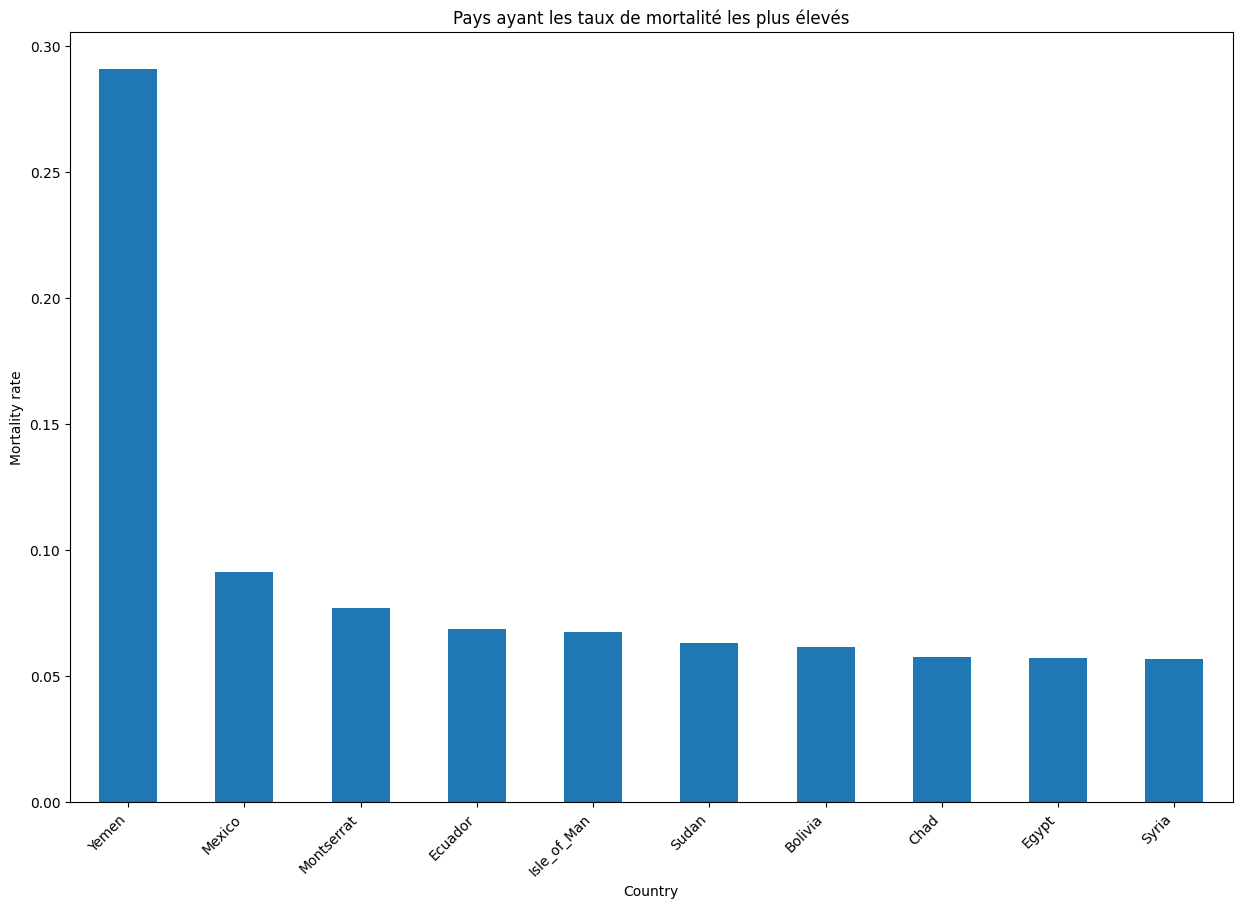

In [23]:
#Visualisation des 10 pays avec les taux de mortalité les plus élevés
plt.figure(figsize=(15,10))
ax = df_by_country['mortality_rate'].sort_values(ascending=False).head(10).plot.bar()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Country")
ax.set_ylabel("Mortality rate")
ax.set_title("Pays ayant les taux de mortalité les plus élevés")

Pays avec le plus de morts

Text(0, 0.5, 'Number of deaths')

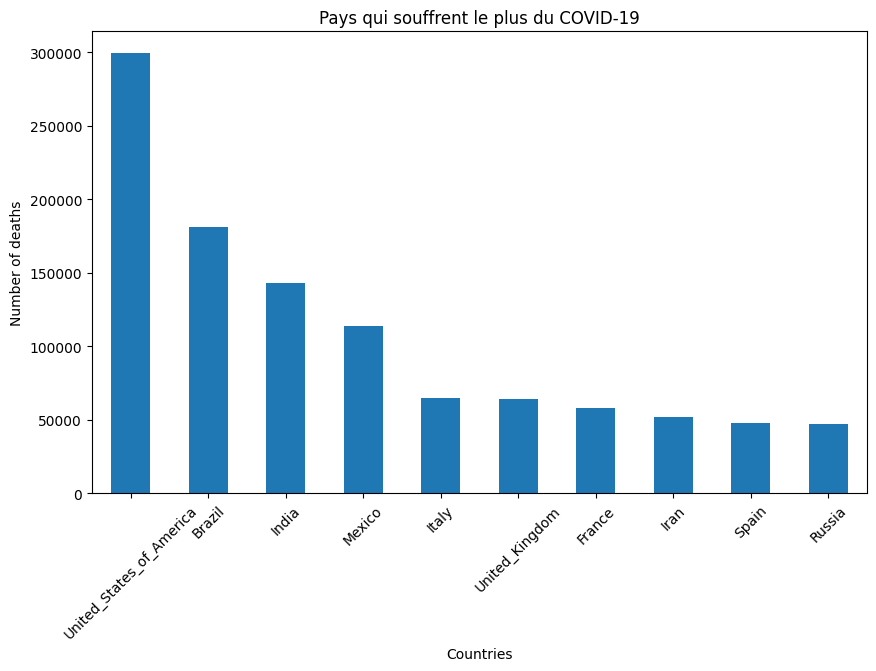

In [24]:
#Visualisation des 10 pays avec les taux de mortalité les plus élevés
plt.figure(figsize=(10,6))
ax=df_by_country['deaths'].sort_values(ascending=False).head(10).plot(kind='bar')#Trier le nombre de décès par ordre décroissant
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Pays qui souffrent le plus du COVID-19")
ax.set_xlabel("Countries")
ax.set_ylabel("Number of deaths")

Effet du confinement sur le nombre de cas

In [29]:
#Groupe les mois par "cases" et "deaths"
df_by_month = df.groupby('month')[['cases','deaths']].sum()

In [30]:
df_by_month

,cases,deaths
month,,
1,9799,213
2,75422,2708
3,723738,35814
4,2339594,189180
5,2891996,140142
6,4249525,134069
7,7067524,166195
8,7963836,178618
9,8456248,162169


Text(0, 0.5, 'Nombre de morts')

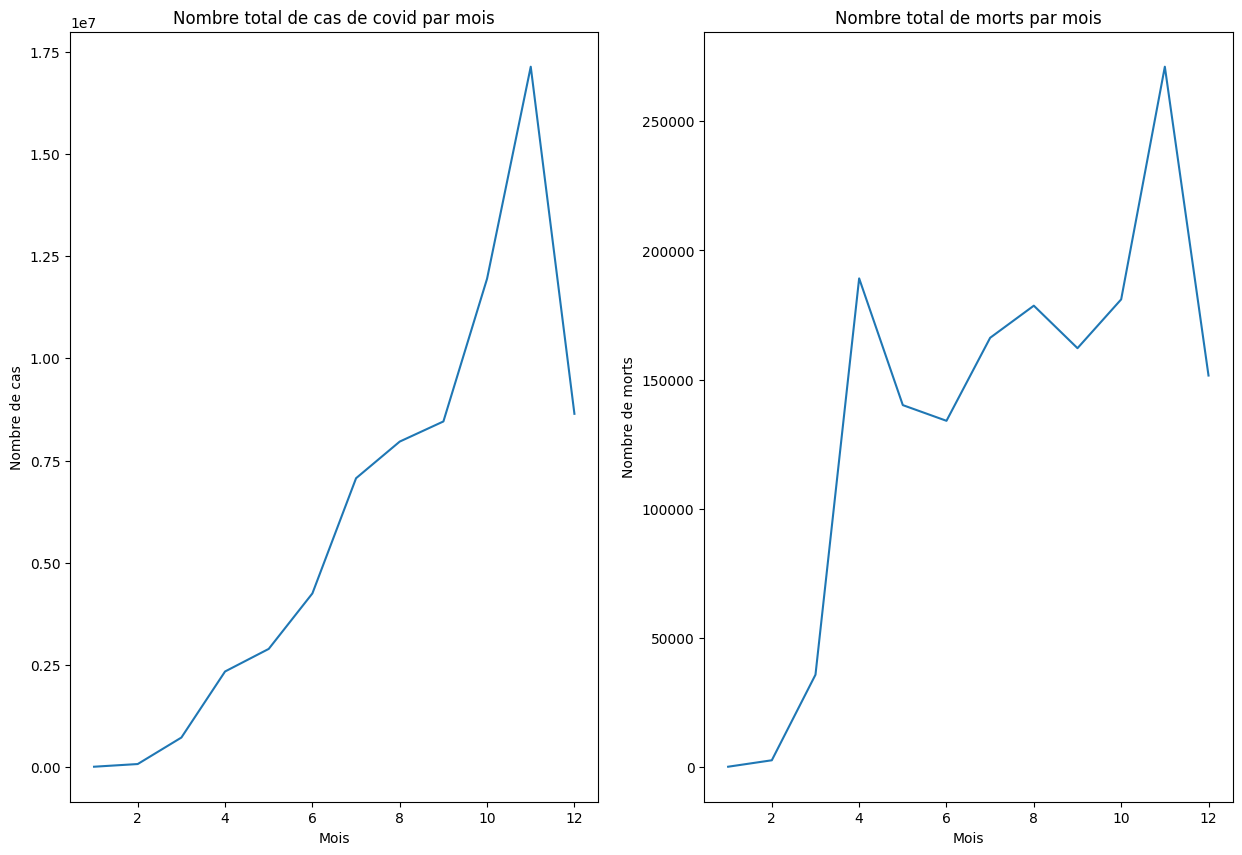

In [31]:
# Affiche le nombre de cas et des morts par graphe
fig=plt.figure(figsize=(15,10))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)

df_by_month['cases'].plot(kind='line',ax=ax1)
ax1.set_title("Nombre total de cas de covid par mois")
ax1.set_xlabel("Mois")
ax1.set_ylabel("Nombre de cas")

df_by_month['deaths'].plot(kind='line',ax=ax2)
ax2.set_title("Nombre total de morts par mois")
ax2.set_xlabel("Mois")
ax2.set_ylabel("Nombre de morts")

Quand on regarde de façon globale on a pas l'impression d'une diminution. Essayons de voir le cas de certains pays(Germany, United_Kingdom, France, Italy) en particulier, qui ont un confinement strict.

In [33]:
#Regroupement mensuel des cas et décès en Allemagne
df_germany = df[df.countriesAndTerritories == 'Germany']
df_germany_monthwise = df_germany.groupby('month')[['cases','deaths']].sum()
df_germany_grouped = df_germany_monthwise.reset_index()

#Regroupement mensuel des cas et décès en United_Kingdom
df_uk = df[df.countriesAndTerritories == 'United_Kingdom']
df_uk_monthwise = df_uk.groupby('month')[['cases','deaths']].sum()
df_uk_grouped = df_uk_monthwise.reset_index()

#Regroupement mensuel des cas et décès en france
df_france = df[df.countriesAndTerritories == 'france']
df_france_monthwise = df_france.groupby('month')[['cases','deaths']].sum()
df_france_grouped = df_france_monthwise.reset_index()

#Regroupement mensuel des cas et décès en Italy
df_italy = df[df.countriesAndTerritories == 'Italy']
df_italy_monthwise = df_italy.groupby('month')[['cases','deaths']].sum()
df_italy_grouped = df_italy_monthwise.reset_index()

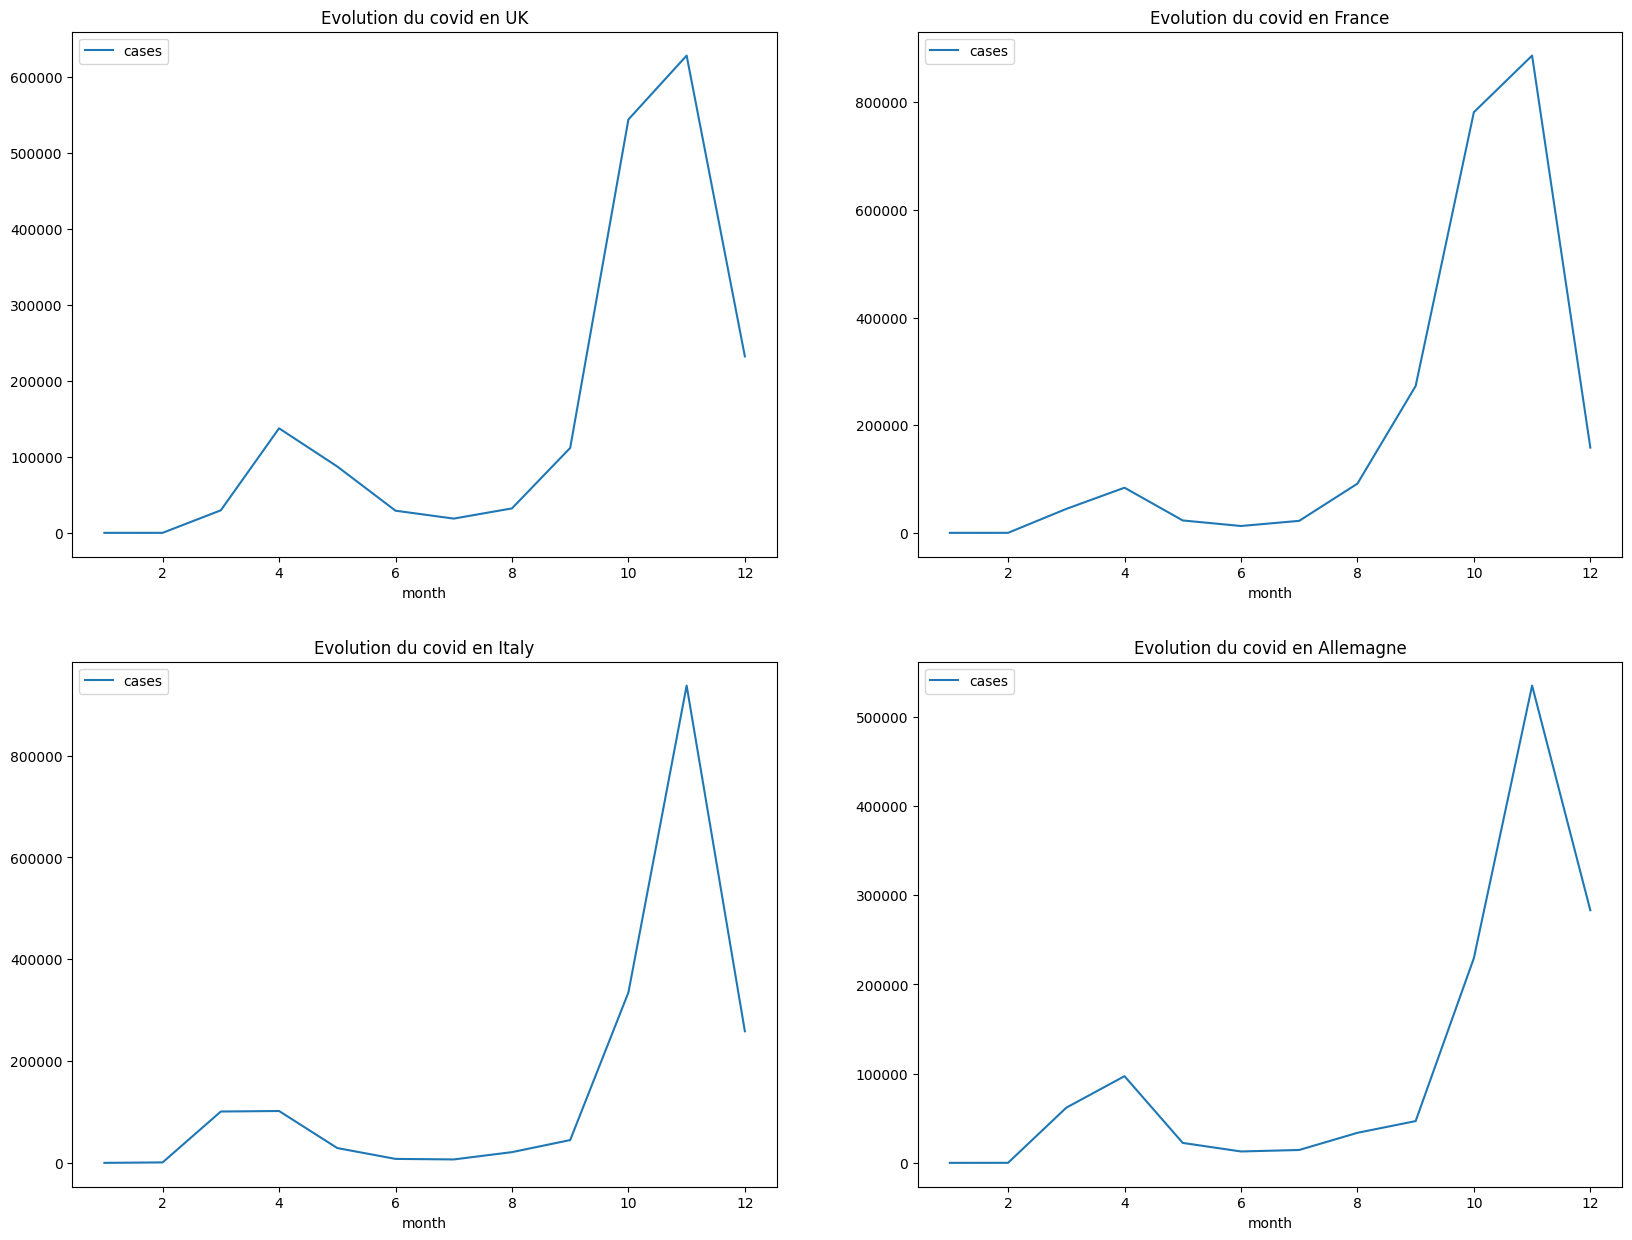

In [ ]:
#Définition de la taille de la figure
fig=plt.figure(figsize=(20,15))

#Courbe des cas de COVID au Uk
ax1=fig.add_subplot(2,2,1)
df_uk_grouped.plot(kind='line',x='month',y='cases',ax=ax1)
ax1.set_title("Evolution du covid en UK")

#Courbe des cas de COVID au France
ax2=fig.add_subplot(2,2,2)
df_france_grouped.plot(kind='line',x='month',y='cases',ax=ax2)
ax2.set_title("Evolution du covid en France")

#Courbe des cas de COVID au Italy
ax3=fig.add_subplot(2,2,3)
df_italy_grouped.plot(kind='line',x='month',y='cases',ax=ax3)
ax3.set_title("Evolution du covid en Italy")

#Courbe des cas de COVID au Allemagne
ax4=fig.add_subplot(2,2,4)
df_germany_grouped.plot(kind='line',x='month',y='cases',ax=ax4)
ax4.set_title("Evolution du covid en Allemagne")
plt.show()

Situation par continent ?

In [ ]:
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object')

In [34]:
#Nombre de cas par continent
df['continentExp'].value_counts()

,count
continentExp,
Europe,17372
Africa,14981
America,13742
Asia,13241
Oceania,2500
Other,64


In [ ]:
#Nombre de cas et morts par continent
df.groupby('continentExp')[['cases', 'deaths']].sum().sort_values('cases',ascending=False)

,cases,deaths
continentExp,,
America,30884895,785370
Europe,21395058,479706
Asia,16780431,290097
Africa,2361775,56134
Oceania,53298,1151
